In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt
# from torchvision.datasets import ImageNet The dataset from the competition AlexNet was specifically made for

In [2]:
torch.manual_seed(41)

In [3]:
train_transforms = T.Compose([
    T.Resize((256,256)), # Standard ImageNet rescaling
    T.RandomCrop(224), # Random cropping (224x224)
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(), # Transforms the PIL image into Tensor (0.0 - 1.0)
    T.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[1.0, 1.0, 1.0]
    ),
])

val_transforms = T.Compose([
    T.Resize((256,256)),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[1.0, 1.0, 1.0]
    )
])

In [4]:
"""
Folder location where both splits of the Imagenette dataset are located

- Imagenette is a subset of 10 easily classified classes from ImageNet(~144-150GB) (tench, English springer, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute)
- The training split of ImageNette contains 9.469 images
- The validation split of ImageNette contains 0,4145 * 9.469 = 3.925 images
Source: https://github.com/fastai/imagenette
Install Link (Full size ~ 1.5GB): https://s3.amazonaws.com/fast-ai-imageclas/imagenette2.tgz
"""

extract_dir='data'

In [5]:
"""ImageFolder instances so that we know the location of both the train and validation splits and link the corresponding transformations"""
train_dataset = datasets.ImageFolder(root=os.path.join(extract_dir, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(root=os.path.join(extract_dir, 'val'), transform=val_transforms)

In [6]:
"""AlexNet standard batch size"""
BATCH_SIZE=16

In [7]:
"""Instantiate the DataLoaders for both the train and val split"""
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.485..0.54301965].


Feature batch shape: torch.Size([16, 3, 224, 224])
Labels batch shape: torch.Size([16])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


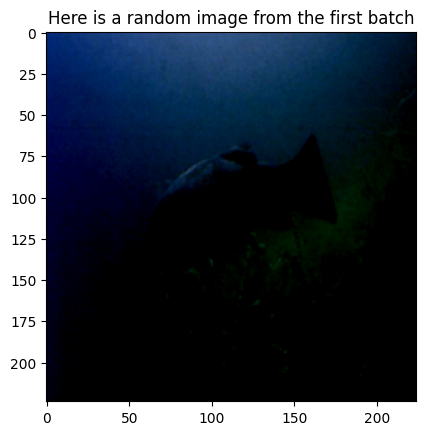

Label: 0


In [8]:
"""Visualizing a random image from the imagenette dataset"""
rand_idx = torch.randint(0, BATCH_SIZE, (1,)).item() # Generates random numbers from 0 to BATCH_SIZE-1; the (1,) parameter basically indicates pytorch to return a tensor with a single element
train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
print(train_features[0].shape)
print(train_features[0].squeeze().shape)
img = train_features[0].squeeze() # [B, H, W] -> [H, W]
img = img.permute(1, 2, 0) # [3, 224, 224] -> [224, 224, 3] | Matplotlib accepts just the Channels-Last format
label = train_labels[0]

plt.imshow(img, cmap='gray')
plt.title("Here is a random image from the first batch")
plt.show()
print(f"Label: {label}")

# Training loop breakdown
- Iterations per epoch: **9.469/128 (batch size) = ~74 steps**
- Total iterations: **74 x 30 (epochs) = 2.220**

In [ ]:
from src.model import AlexNet

model = AlexNet(num_classes=10) # Imagenette contains 10 labels
train_loss, val_loss, y_true, y_pred = model.fit(train_loader=train_loader, val_loader=val_loader, device='gpu', track=True, epochs=30)

AlexNet training will start on: CPU
Epoch: 1 | Batch: 000 | Batch Loss: 2.3036


: 

In [ ]:
"""Save the model weights using the class method"""
model.save() # Creates a file named "alexnet_model.pth" that contains the state dictionary

## Let's now visualize the loss on both train and validation splits of Imagenette ## 

In [ ]:
"""Mostly boilerplate/boring matplotlib code"""
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(train_loss, label='Loss', color='blue', linewidth=1)

ax.set_title("Loss Evolution during AlexNet Training")
ax.set_xlabel("Iterations")
ax.set_ylabel('Loss Value')
ax.grid(True, linestyle='--', alpha=0.6)
for i in range(30):
    ax.annotate(f'Epoch {i}', xy=(i-1, train_loss[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black', shrink=0.05))
ax.legend()
plt.show()


In [ ]:
"""Mostly boilerplate/boring matplotlib code"""
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(val_loss, label='Loss', color='blue', linewidth=1)

ax.set_title("Loss Evolution during AlexNet Training")
ax.set_xlabel("Iterations")
ax.set_ylabel('Loss Value')
ax.grid(True, linestyle='--', alpha=0.6)
for i in range(30):
    ax.annotate(f'Epoch {i}', xy=(i-1, val_loss[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black', shrink=0.05))
ax.legend()
plt.show()


# The Confusion Matrix

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_mat = confusion_matrix(y_true, y_pred)

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(10)], yticklabels=[str(i) for i in range(10)])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Classification Report

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

In [ ]:
cls_rep = classification_report(y_true, y_pred)

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(pd.Dataframe(classification_report(y_true, y_pred, output_dict=True)).iloc[:-1, :].T, cmap='mako', annot=True)
plt.xlabel("Metrics")
plt.ylabel("Classes")
plt.show()